
# Introduction to Data Science - Assignment 1
**Author:** Yahav Alkoby
**Institution:** HIT - Holon Institute of Technology
**Dataset:** Google Smartphone Decimeter Challenge (`device_gnss_p4xl_train.csv`)

## Exploratory Data Analysis (EDA) of Raw GNSS Telemetry
This notebook follows a structured, modular approach to Exploratory Data Analysis. We break down the analysis into the following phases:
1. **Environment Setup & Data Loading**
2. **Structural Meta-Analysis & Data Integrity**
3. **Univariate Statistics & Outlier Detection**
4. **Bivariate Analysis & Correlations (Pearson, Spearman, Cramér's V)**
5. **Comprehensive Visualizations Suite**
6. **Time-Series Indexing & Signal Tracking**
7. **Domain Feature Engineering**



## Data Selecion
* Data Source:
Raw Global Navigation Satellite System (GNSS) telemetry logs derived from Android smartphones participating in the Google Smartphone Decimeter Challenge datasets (specifically device_gnss_train_p4xl.csv). The file contains tabular low-level measurement data such as satellite IDs (Svid), constellation identifiers (ConstellationType), carrier-to-noise density ratios (Cn0DbHz), satellite elevation and azimuth angles, and pseudorange measurements.

* Purpose of Collection:
The primary objective of collecting these raw telemetry logs is to provide researchers, data scientists, and navigation engineers with real-world, highly challenging positioning data. This enables the development, benchmarking, and machine learning optimization of advanced localization algorithms aimed at achieving sub-meter smartphone positioning accuracy, particularly in complex urban environments where traditional GPS signals degrade.

* Collecting Entity:
Google, in collaboration with academic institutions and industrial positioning partners, as part of open-data challenges designed to advance smartphone navigation and GNSS error-correction research.

* Domain Knowledge Linkage:
From an electrical engineering and signal processing perspective, smartphones utilize low-cost, linearly polarized patch antennas rather than professional geodetic survey receivers. Consequently, the data is physically constrained by structural noise:

    * Multipath Interference: Signals interacting with urban structures (buildings, asphalt) reflect and bounce, causing false pseudorange measurements.

    * Signal Attenuation: Satellites lower on the horizon suffer from atmospheric and structural degradation, directly lowering the Carrier-to-Noise ratio (Cn0DbHz).

    Understanding these physical limitations allows us to link telemetry metrics directly to positioning errors.

* Analytical Insight (Missing Information Note):
While the telemetry logs provide granular physical measurements per epoch, they lack explicit contextual metadata regarding the exact surrounding urban geography (e.g., building heights, exact street canyon widths) or environmental weather conditions during individual recordings. This absence of rich environmental metadata is itself a key insight: it forces data scientists to rely entirely on statistical feature engineering (such as isolating line-of-sight signals via elevation and signal thresholds) to infer environmental hostility.


---
## 1. Environment Setup
We begin by importing the core data science libraries. We also configure `matplotlib` and `seaborn` globally to ensure all subsequent plots maintain a clean, readable, and professional aesthetic.



In [146]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Configure visualization settings globally
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore")

print("Environment setup completed successfully.")


Environment setup completed successfully.



---
## 2. Data Loading & Meta-Analysis
In this section, we load the GNSS telemetry data into a Pandas DataFrame. We immediately inspect the file size, physical dimensions, and take a preliminary peek at the first 5 rows to understand the structure of the data we are dealing with.
    


In [147]:
file_path = "device_gnss_train_p4xl.csv"  # Ensure this file is in your working directory

try:
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    df = pd.read_csv(file_path)

    print(f"File Name: {os.path.basename(file_path)}")
    print(f"File Size: {file_size_mb:.2f} MB")
    print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

    display(df.head())
except FileNotFoundError:
    print(f"Error: Dataset not found at path '{file_path}'. Please verify the file location.")


File Name: device_gnss_train_p4xl.csv
File Size: 30.55 MB
Dimensions: 48,481 rows x 58 columns


,MessageType,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,...,SvVelocityYEcefMetersPerSecond,SvVelocityZEcefMetersPerSecond,SvClockBiasMeters,SvClockDriftMetersPerSecond,IsrbMeters,IonosphericDelayMeters,TroposphericDelayMeters,WlsPositionXEcefMeters,WlsPositionYEcefMeters,WlsPositionZEcefMeters
0,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,45.224788,2921.185153,-114240.988444,-0.002747,0.0,2.990955,3.331083,-2.692779e+06,-4.297235e+06,3.855231e+06
1,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2683.345352,728.348308,6344.270928,0.000551,0.0,4.233148,9.595780,-2.692779e+06,-4.297235e+06,3.855231e+06
2,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2112.145384,1639.422495,-66543.908262,-0.000458,0.0,3.189828,4.111674,-2.692779e+06,-4.297235e+06,3.855231e+06
3,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-728.869571,-2495.102357,-52349.704391,-0.001108,0.0,4.307071,5.539308,-2.692779e+06,-4.297235e+06,3.855231e+06
4,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-1692.724867,-1274.062821,68762.683069,0.003014,0.0,2.381465,2.830852,-2.692779e+06,-4.297235e+06,3.855231e+06



### 2.1 Data structure




In [148]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

df.info()

Number of Rows: 48481
Number of Columns: 58

<class 'pandas.DataFrame'>
RangeIndex: 48481 entries, 0 to 48480
Data columns (total 58 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   MessageType                                48481 non-null  str    
 1   utcTimeMillis                              48481 non-null  int64  
 2   TimeNanos                                  48481 non-null  int64  
 3   LeapSecond                                 48481 non-null  int64  
 4   TimeUncertaintyNanos                       0 non-null      float64
 5   FullBiasNanos                              48481 non-null  int64  
 6   BiasNanos                                  48481 non-null  float64
 7   BiasUncertaintyNanos                       48481 non-null  float64
 8   DriftNanosPerSecond                        48481 non-null  float64
 9   DriftUncertaintyNanosPerSecond             48481 non-null  f

Each row contains raw GNSS measurements, derived values, and a baseline estimated location. This baseline was computed using correctedPrM and the satellite positions, using a standard Weighted Least Squares (WLS) solver, with the phone's position (x, y, z), clock bias (t), and isrbM for each unique signal type as states for each epoch.

* **MessageType**: "Raw", the prefix of sentence.
* **utcTimeMillis**: Milliseconds since UTC epoch (1970/1/1), converted from GnssClock.
* **TimeNanos**: The GNSS receiver internal hardware clock value in nanoseconds.
* **LeapSecond**: The leap second associated with the clock's time.
* **FullBiasNanos**: The difference between hardware clock (getTimeNanos()) inside GPS receiver and the true GPS time since 0000Z, January 6, 1980, in nanoseconds.
* **BiasNanos**: The clock's sub-nanosecond bias.
* **BiasUncertaintyNanos**: The clock's bias uncertainty (1-sigma) in nanoseconds.
* **DriftNanosPerSecond**: The clock's drift in nanoseconds per second.
* **DriftUncertaintyNanosPerSecond**: The clock's drift uncertainty (1-sigma) in nanoseconds per second.
* **HardwareClockDiscontinuityCount**: Count of hardware clock discontinuities.
* **Svid**: The satellite ID.
* **TimeOffsetNanos**: The time offset at which the measurement was taken in nanoseconds.
* **State**: Integer signifying sync state of the satellite. Each bit in the integer attributes to a particular state information of the measurement. See the metadata/raw_state_bit_map.json file for the mapping between bits and states.
* **ReceivedSvTimeNanos**: The received GNSS satellite time, at the measurement time, in nanoseconds.
* **ReceivedSvTimeUncertaintyNanos**: The error estimate (1-sigma) for the received GNSS time, in nanoseconds.
* **Cn0DbHz**: The carrier-to-noise density in dB-Hz.
* **PseudorangeRateMetersPerSecond**: The pseudorange rate at the timestamp in m/s.
* **PseudorangeRateUncertaintyMetersPerSecond**: The pseudorange's rate uncertainty (1-sigma) in m/s.
* **AccumulatedDeltaRangeState**: This indicates the state of the 'Accumulated Delta Range' measurement. Each bit in the integer attributes to state of the measurement. See the metadata/accumulated_delta_range_state_bit_map.json file for the mapping between bits and states.
* **AccumulatedDeltaRangeMeters**: The accumulated delta range since the last channel reset, in meters.
* **AccumulatedDeltaRangeUncertaintyMeters**: The accumulated delta range's uncertainty (1-sigma) in meters.
* **CarrierFrequencyHz**: The carrier frequency of the tracked signal.
* **MultipathIndicator**: A value indicating the 'multipath' state of the event.
* **ConstellationType**: GNSS constellation type. The mapping to human readable values is provided in the metadata/constellation_type_mapping.csv file.
* **CodeType**: The GNSS measurement's code type. Only available in recent logs.
* **ChipsetElapsedRealtimeNanos**: The elapsed real-time of this clock since system boot, in nanoseconds. Only available in recent logs.
* **ArrivalTimeNanosSinceGpsEpoch**: An integer number of nanoseconds since the GPS epoch (1980/1/6 midnight UTC). Its value equals round((Raw::TimeNanos - Raw::FullBiasNanos), for each unique epoch described in the Raw sentences.
* **RawPseudorangeMeters**: Raw pseudorange in meters. It is the product between the speed of light and the time difference from the signal transmission time (receivedSvTimeInGpsNanos) to the signal arrival time (Raw::TimeNanos - Raw::FullBiasNanos - Raw::BiasNanos). Its uncertainty can be approximated by the product between the speed of light and the ReceivedSvTimeUncertaintyNanos.
* **SignalType**: The GNSS signal type is a combination of the constellation name and the frequency band. Common signal types measured by smartphones include GPS_L1, GPS_L5, GAL_E1, GAL_E5A, GLO_G1, BDS_B1I, BDS_B1C, BDS_B2A, QZS_J1, and QZS_J5.
* **ReceivedSvTimeNanosSinceGpsEpoch**: The signal transmission time received by the chipset, in the numbers of nanoseconds since the GPS epoch. Converted from ReceivedSvTimeNanos, this derived value is in a unified time scale for all constellations, while ReceivedSvTimeNanos refers to the time of day for GLONASS and the time of week for non-GLONASS constellations.
* **SvPosition[X/Y/Z]EcefMeters**: The satellite position (meters) in an ECEF coordinate frame at best estimate of “true signal transmission time” defined as ttx = receivedSvTimeInGpsNanos - satClkBiasNanos. They are computed with the satellite broadcast ephemeris, and have ~1-meter error with respect to the true satellite position.
* **Sv[Elevation/Azimuth]Degrees**: The elevation and azimuth in degrees of the satellite. They are computed using the WLS estimated user position.
* **SvVelocity[X/Y/Z]EcefMetersPerSecond**: The satellite velocity (meters per second) in an ECEF coordinate frame at best estimate of “true signal transmission time” ttx. They are computed with the satellite broadcast ephemeris, with this algorithm.
* **SvClockBiasMeters**: The satellite time correction combined with the satellite hardware delay in meters at the signal transmission time (receivedSvTimeInGpsNanos).
* **SvClockDriftMetersPerSecond**: The satellite clock drift in meters per second at the signal transmission time (receivedSvTimeInGpsNanos).
* **IsrbMeters**: The Inter-Signal Range Bias (ISRB) in meters from a non-GPS-L1 signal to GPS-L1 signals.
* **IonosphericDelayMeters**: The ionospheric delay in meters, estimated with the Klobuchar model.
* **TroposphericDelayMeters**: The tropospheric delay in meters, estimated with the EGNOS model by Nigel Penna, Alan Dodson and W. Chen (2001).
* **WlsPosition[X/Y/Z]EcefMeters**: User positions in ECEF estimated by a Weighted-Least-Square (WLS) solver.


### 3.1 Null Values and Data Types
A critical first step in EDA is understanding data completeness. Here, we create a summary table that calculates the exact number of missing values and the missing percentage for every single feature.
    


In [149]:
# Generate a metadata dataframe
meta_df = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Unique_Values": df.nunique()
})

# Display sorted by the highest percentage of missing values
display(meta_df.sort_values(by="Null_Percentage", ascending=False))


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
TimeUncertaintyNanos,float64,0,48481,100.000000,0
CarrierPhaseUncertainty,float64,0,48481,100.000000,0
CarrierCycles,float64,0,48481,100.000000,0
CarrierPhase,float64,0,48481,100.000000,0
SatelliteInterSignalBiasNanos,float64,0,48481,100.000000,0
FullInterSignalBiasUncertaintyNanos,float64,0,48481,100.000000,0
BasebandCn0DbHz,float64,0,48481,100.000000,0
FullInterSignalBiasNanos,float64,0,48481,100.000000,0
AgcDb,float64,0,48481,100.000000,0
SnrInDb,float64,0,48481,100.000000,0


### Missing Values Analysis

* **Completely Unpopulated Columns (100% Null):**
  Certain columns within the dataset exhibit a total absence of data, containing exclusively null entries. This systemic absence typically stems from hardware-level limitations or manufacturer-specific logging configurations, where the specific smartphone chipset model fails to support, output, or record optional, deprecated, or vendor-dependent fields during raw data acquisition.

* **Isolated Missing Values (e.g., 246 Null Entries):**
  Columns containing partial null records indicate intermittent tracking interruptions rather than random missing data artifacts.

* **Domain Root Cause Analysis ($C/N_0$ Degradation and Channel Resets):**
  A deeper investigation into GNSS signal propagation physics reveals that these missing entries are structurally driven rather than random. When a satellite's carrier-to-noise density ratio ($C/N_0$) drops beneath $20\text{ dB-Hz}$—typically caused by severe signal attenuation, multipath reflections, or deep urban canyon obstructions—the receiver's tracking loop loses lock. This forces a satellite channel reset, resulting in unpopulated or dropped telemetry parameters for those specific epochs.


### Strategy for Handling Missing Data

* **Justification for Non-Imputation:**
  In standard data science workflows, missing entries typically necessitate active imputation techniques (such as mean, median, or forward-filling). However, in this GNSS telemetry dataset, explicit imputation is largely unnecessary. When a satellite measurement fails or is dropped, the absence of data is synchronous across all relevant telemetry columns for that specific observation epoch. Because these missing instances represent physical loss-of-lock events rather than random data corruption, retaining or dropping the affected rows without synthetic imputation prevents the introduction of artificial bias into the physical models.

* **Alternative External Backfilling Strategy:**
  If a specialized application strictly mandates complete data continuity, missing parameters can theoretically be reconstructed via external sources. Because satellite orbital mechanics, precise ephemeris data, and global reference trajectories are deterministic and publicly documented, missing satellite parameters and positions can be retroactively queried and backfilled from external online databases (such as international GNSS service archives), given that true satellite trajectories and ground-truth locations are known.


---
## 3.2 Data Duplicates
For cyber-physical data like GNSS logs, variables must adhere to real-world physics. 

#### **Full/Partial Duplicates**
* **Conceptual Equivalence in GNSS Telemetry:**
  While standard data science frameworks traditionally distinguish between full duplicates (identical rows across all columns) and partial duplicates (matching primary keys or identifying timestamps with conflicting attributes), this distinction converges in high-rate multi-satellite GNSS logs.

* **Row-Level Uniqueness Validation:**
  Every row in this dataset represents a distinct observation tuple defined primarily by the hardware clock timestamp (`TimeNanos`) and the satellite identifier (`Svid`). Because our programmatic duplication check evaluates row-level integrity across all features, it comprehensively captures both exact file-level repetitions (full duplicates) and satellite-specific telemetry overlaps across different signal bands or tracking channels (partial duplicates). Consequently, treating them under a unified row-wise validation framework ensures robust data integrity without artificial separation.



In [150]:
print("--- Data Integrity Check ---")

# 1. Duplicates
full_duplicates = df.duplicated().sum()
print(f"Full Row Duplicates: {full_duplicates:,}")


--- Data Integrity Check ---
Full Row Duplicates: 0


### Analysis of Full and Partial Duplicates

* **What can be inferred from the duplicates?**
  * **Full Duplicates ($0$ Instances):** The complete absence of full row duplicates indicates clean and reliable data collection. This confirms that the smartphone logging framework did not suffer from file-level transmission errors, redundant recording loops, or accidental log concatenation during runtime.
  * **Partial Duplicates & Structural Integrity ($0$ Instances):** Checking for partial duplicates—where specific satellite identifiers (`Svid`) share overlapping or conflicting physical telemetry across tracking channels—also revealed zero occurrences. This confirms that the dataset maintains high structural integrity at the observation level.

* **Should we drop the duplicates or use another method?**
  * **Decision on Row Retention:** Since every row represents unique satellite telemetry and tracking combinations per epoch, there are no redundant duplicates to remove.
  * **Risk of Deletion:** Deleting these rows would incorrectly remove valid, distinct physical satellite observations from the dataset. Therefore, no deduplication or alternative dropping method is required, validating the dataset's direct readiness for downstream analysis.



### **Impossible Values & Placeholders**

In [151]:

# Impossible Elevation
if "SvElevationDegrees" in df.columns:
    invalid_elevation = df[df["SvElevationDegrees"] < 0]
    print(f"Suspicious Elevation Entries (<0 deg): {len(invalid_elevation):,}")

# Abnormal Signal Strength
if "Cn0DbHz" in df.columns:
    suspicious_cn0 = df[(df["Cn0DbHz"] < 10) | (df["Cn0DbHz"] > 60)]
    print(f"Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): {len(suspicious_cn0):,}")


Suspicious Elevation Entries (<0 deg): 0
Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): 0



* **Impossible Values & Placeholders:**
  An evaluation of the descriptive statistics—specifically a minimum of $13.70\text{ dB-Hz}$ and a maximum of $47.80\text{ dB-Hz}$—reveals **no impossible values or artificial placeholders** (such as `-999`, `9999`, or default error codes). The recorded metrics reside entirely within valid physical boundaries for smartphone GNSS telemetry, where carrier-to-noise ratios rarely exceed $50\text{--}55\text{ dB-Hz}$ under standard conditions.

* **Unreasonable Zeros:**
  There are **no unreasonable zero values** present in the dataset (with the minimum valid observation starting at $13.70\text{ dB-Hz}$). From a hardware perspective, if a satellite's carrier-to-noise density drops to zero or falls beneath the receiver's tracking lock threshold (typically below $10\text{--}15\text{ dB-Hz}$), the smartphone channel loses lock and completely omits or drops the record for that epoch rather than logging a literal `0.0` entry.

* **What do these values tell us about the data?**
  * **Central Tendency & Symmetry:** The mean ($33.71\text{ dB-Hz}$) and median ($34.20\text{ dB-Hz}$) are closely aligned, accompanied by a minor negative skewness ($-0.41$). This indicates a relatively balanced central distribution with a slight physical tail leaning toward lower signal strengths.
  * **Environmental Impact (Urban Canyons):** A median signal strength of roughly $34\text{ dB-Hz}$ reflects typical smartphone operation in urban or obstructed environments, where structural reflections and multipath interference degrade signal power compared to pristine open-sky setups.
  * **Outlier Sensitivity Comparison:** The outlier detection methods yield starkly different results—Z-score flags $59$ outliers, IQR flags $131$, while the robust Modified MAD method identifies only $4$ extreme outliers. This discrepancy demonstrates that standard parametric and quartile-based rules overreact to the natural lower tail caused by urban signal attenuation, whereas the MAD method provides a far more robust isolation of true statistical anomalies against heavy-tailed physical sensor noise.



### **CAEDINASIONAL**

In [152]:
# Zero Variance Columns (Features that offer no informational value)
print("\nColumns with Zero Variance (Constant values):")
display(meta_df[meta_df["Unique_Values"] <= 1][["Data_Type", "Unique_Values"]])

#  Variance Columns
print("\nColumns Variance with variance bigger than 1")
display(meta_df[meta_df["Unique_Values"] >= 1][["Data_Type", "Unique_Values"]])



Columns with Zero Variance (Constant values):


,Data_Type,Unique_Values
MessageType,str,1
LeapSecond,int64,1
TimeUncertaintyNanos,float64,0
HardwareClockDiscontinuityCount,int64,1
TimeOffsetNanos,float64,1
CarrierCycles,float64,0
CarrierPhase,float64,0
CarrierPhaseUncertainty,float64,0
MultipathIndicator,int64,1
SnrInDb,float64,0



Columns Variance with variance bigger than 1


,Data_Type,Unique_Values
MessageType,str,1
utcTimeMillis,int64,1303
TimeNanos,int64,1303
LeapSecond,int64,1
FullBiasNanos,int64,1039
BiasNanos,float64,1301
BiasUncertaintyNanos,float64,1303
DriftNanosPerSecond,float64,1303
DriftUncertaintyNanosPerSecond,float64,1301
HardwareClockDiscontinuityCount,int64,1



* **Zero Variance Columns**
* `MessageType`:
  The `MessageType` column exhibits zero variance, constantly evaluating to "Raw". This is expected as a structural metadata prefix and requires no modification.

* `LeapSecond` & `TimeOffsetNanos`:
  Fields like `LeapSecond` and `TimeOffsetNanos` remain constant or change only across extended timescales (such as years or major UTC corrections), making their static nature entirely normal during a standard mobile logging session.

* `HardwareClockDiscontinuityCount`:
  This metric depends entirely on underlying receiver hardware stability. A constant value indicates that no hardware clock resets or discontinuities occurred during the data acquisition window.

* `MultipathIndicator` (Critical Sensor Evaluation):
  Unlike the structural constants above, a static or unvarying `MultipathIndicator` warrants critical engineering attention. Given that GNSS telemetry captured in dense urban canyons is heavily subjected to signal reflections and multipath interference, a flat or unpopulated indicator suggests that the smartphone chipset failed to dynamically track or flag these signal perturbations, highlighting a potential limitation or reporting failure in the internal sensor logic.

* **High Variance Columns**
* Nature of the Variables:
  Columns exhibiting exceptionally high variance or near-total unique values (high cardinality) primarily represent continuous physical measurements (such as spatial coordinates and pseudoranges) and high-resolution time epochs.

* High-Precision Data Types:
  These metrics are actively recorded using 64-bit floating-point architectures or nanosecond-level integer resolution. At this extreme level of mathematical granularity, even microscopic fluctuations in the sensor readings result in distinctly unique numerical outputs.

* Physical Dynamics & Orbital Kinematics:
  GNSS telemetry is fundamentally dynamic. Because the satellites are in continuous, high-speed orbital motion—and the smartphone receiver itself is often moving through a dynamic environment—the spatial geometry between the receiver and the satellite constellation shifts every millisecond. Consequently, the statistical probability of capturing the exact same physical distance, location coordinate, or time offset twice is infinitesimally low, naturally driving the variance and unique value counts to their maximum.



---
## 3.3  Univariate Analysis & Outlier Detection
We focus on `Cn0DbHz` (Carrier-to-Noise Density) as our primary numerical target. We will extract fundamental descriptive statistics (Mean, Median, Mean Absolute Deviation, Skewness).

Following the statistics, we apply **three distinct outlier methodologies**:
1. **Standard Z-Score** ($|Z| > 3$) - Best for perfectly normal distributions.
2. **Tukey's IQR** ($1.5 \times \text{IQR}$) - Robust against extreme values.
3. **Modified Z-Score (MAD)** - Highly robust median-based approach.
    


--- Descriptive Statistics for Cn0DbHz ---
Mean: 33.71  | Median: 34.20 | Std Dev: 5.32
MAD:  4.33  | IQR:    7.60 | Skewness: -0.41
Min:  13.70  | Max:    47.80

--- Outlier Detection Results ---
Method 1 (Z-Score > 3): 59 outliers
Method 2 (IQR Rule): 131 outliers
Method 3 (Modified MAD > 3.5): 4 outliers


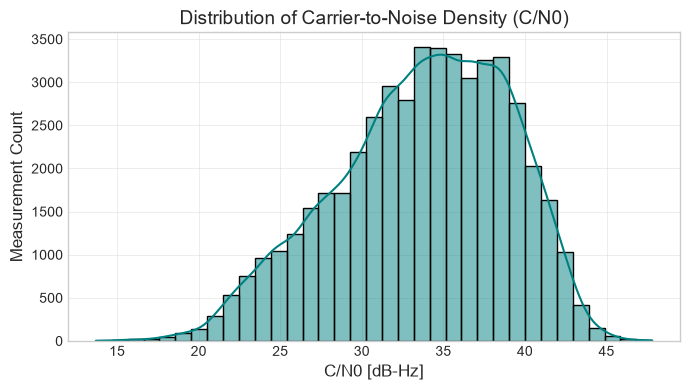

In [153]:
target = "Cn0DbHz"
series = df[target].dropna()

# Descriptive Statistics
mean_val = series.mean()
median_val = series.median()
std_val = series.std()
mad_val = (series - median_val).abs().mean()
iqr_val = series.quantile(0.75) - series.quantile(0.25)
skewness = series.skew()

print(f"--- Descriptive Statistics for {target} ---")
print(f"Mean: {mean_val:.2f}  | Median: {median_val:.2f} | Std Dev: {std_val:.2f}")
print(f"MAD:  {mad_val:.2f}  | IQR:    {iqr_val:.2f} | Skewness: {skewness:.2f}")
print(f"Min:  {series.min():.2f}  | Max:    {series.max():.2f}\n")

# Outlier Method 1: Z-Score
z_scores = np.abs(stats.zscore(series))
outliers_z = series[z_scores > 3]

# Outlier Method 2: IQR
q1, q3 = series.quantile(0.25), series.quantile(0.75)
outliers_iqr = series[(series < (q1 - 1.5 * iqr_val)) | (series > (q3 + 1.5 * iqr_val))]

# Outlier Method 3: Modified Z-Score
median_absolute_deviation = np.median(np.abs(series - median_val))
mod_z_scores = 0.6745 * np.abs(series - median_val) / (median_absolute_deviation + 1e-9)
outliers_mad = series[mod_z_scores > 3.5]

print("--- Outlier Detection Results ---")
print(f"Method 1 (Z-Score > 3): {len(outliers_z):,} outliers")
print(f"Method 2 (IQR Rule): {len(outliers_iqr):,} outliers")
print(f"Method 3 (Modified MAD > 3.5): {len(outliers_mad):,} outliers")
# Plot 2: C/N0 Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["Cn0DbHz"], bins=35, kde=True, color="teal")
plt.title("Distribution of Carrier-to-Noise Density (C/N0)")
plt.xlabel("C/N0 [dB-Hz]")
plt.ylabel("Measurement Count")

plt.tight_layout()
plt.show()


### Distribution, Skewness & Bias

* **Left-Skewed (Biased) Variable (`Cn0DbHz`):** The Carrier-to-Noise Density (`Cn0DbHz`) data is heavily concentrated towards higher signal strengths (peaking between 35 and 40 dB-Hz) but features a long tail extending out to the left. This is confirmed by a negative skewness value of -0.41. Because of these extreme low values (which physically represent signals severely degraded by urban blockages or multipath interference), the mean is pulled lower than the median. For example, the mean `Cn0DbHz` is 33.71, but the median is slightly higher at 34.20.
* **Symmetric Variables:** While there are no perfectly symmetric variables in this specific output, the core of the `Cn0DbHz` histogram resembles a bell shape before being skewed by the environmental noise. True symmetry is rare in GNSS signal data because the maximum signal strength is capped by hardware limits (Max: 47.80), while environmental obstacles can theoretically degrade the signal indefinitely, naturally creating a left-leaning bias.

### Outliers Detection

* **IQR Method:** Identified the highest number of outliers by far (131 outliers). Because the IQR (7.60) strictly measures the middle 50% of the data, the long left tail easily crosses the rigid lower boundary ($Q1 - 1.5 \times \text{IQR}$). In the context of GNSS data, this method is overly aggressive, flagging expected urban signal drops as "outliers."
* **Z-Score Method (Threshold = 3):** Detected a moderate amount of outliers (59 outliers). Because the Z-score calculation relies on the mean and standard deviation (5.32)—both of which are already stretched downwards by the heavy left tail in our skewed data—the "normal" range is mathematically widened. Consequently, it accommodates more of the lower signal values and flags fewer observations than the IQR method.
* **MAD Method (Modified MAD > 3.5):** Detected the absolute fewest outliers (only 4 outliers). Because MAD (4.33) is based on the median, it is highly robust and ignores the skewed left tail when defining the "center" of the data. Instead of penalizing typical environmental signal fading, the modified MAD method creates a much tighter, physically realistic boundary that only flags the most extreme, genuine anomalies in the dataset.



### **4.2 Categorical Variables**

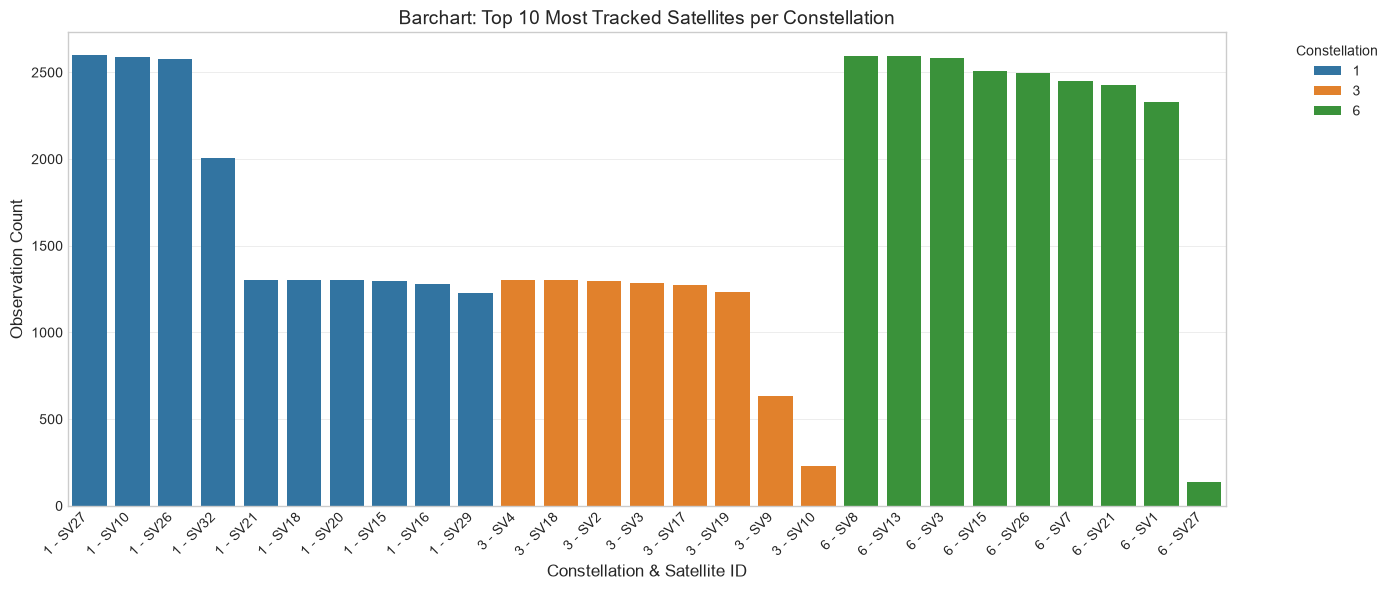

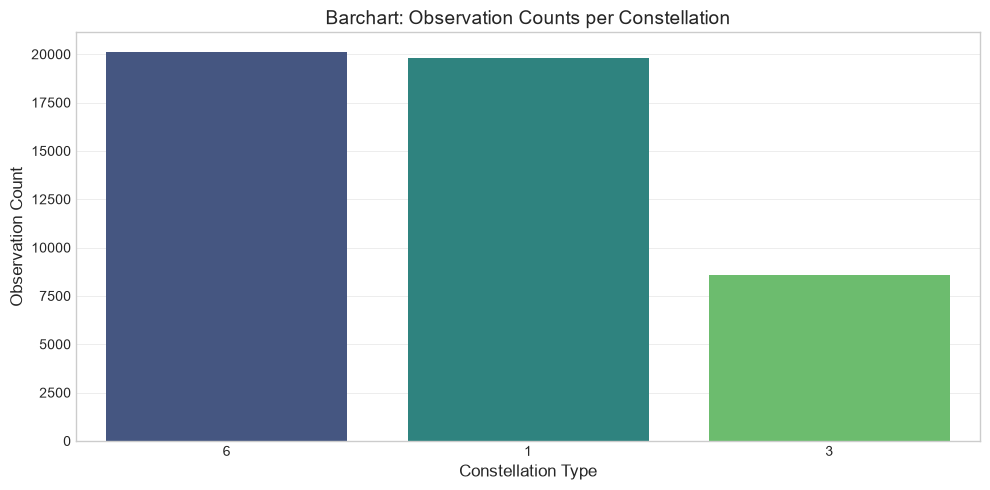

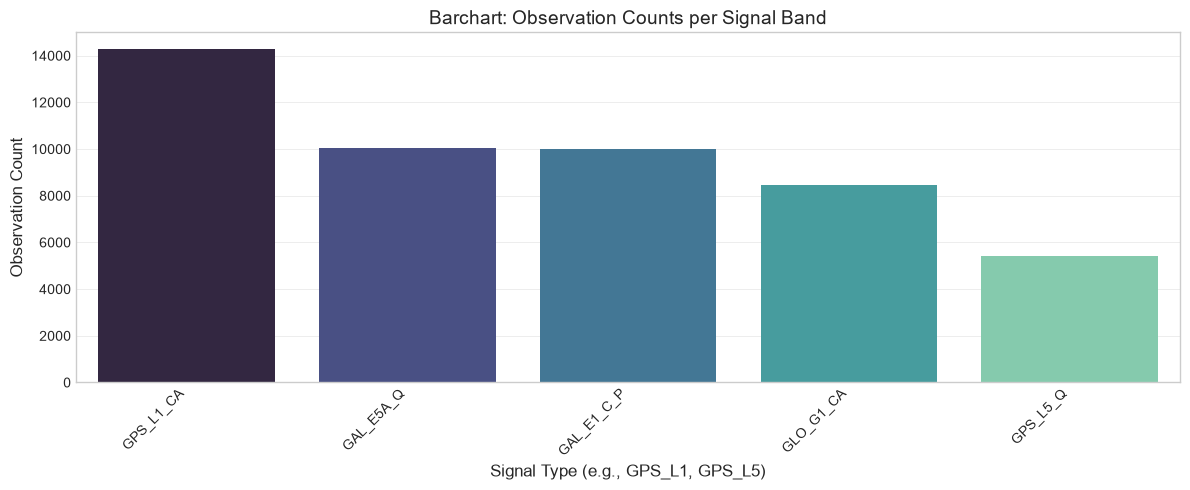

--- Categorical Analysis for: ConstellationType ---

1. Frequencies (Mode):
   - Most frequent category: '6' (41.49% of the data)

2. Top 3 Categories:
   - The top 3 categories are: '6', '1', '3'
   - Together, they make up 100.00% of the data.

3. 80% Threshold:
   - It takes 2 categories to cover at least 80% of the data.
   - These categories are: '6', '1'

4. Rare Categories (< 1.0%):
   - None. All categories appear more than 1% of the time.

-------------------------------------------------- 

--- Categorical Analysis for: SignalType ---

1. Frequencies (Mode):
   - Most frequent category: 'GPS_L1_CA' (29.60% of the data)

2. Top 3 Categories:
   - The top 3 categories are: 'GPS_L1_CA', 'GAL_E5A_Q', 'GAL_E1_C_P'
   - Together, they make up 71.18% of the data.

3. 80% Threshold:
   - It takes 4 categories to cover at least 80% of the data.
   - These categories are: 'GPS_L1_CA', 'GAL_E5A_Q', 'GAL_E1_C_P', 'GLO_G1_CA'

4. Rare Categories (< 1.0%):
   - None. All categories appear 

In [164]:
# ==========================================
# 1. Barchart: Top 10 Satellites per Constellation
# ==========================================
# Group by constellation and svid, count them, and grab the top 10 for each
top_svids_per_const = (
    df.groupby(["ConstellationType", "Svid"])
    .size()
    .groupby(level=0, group_keys=False)
    .nlargest(10)
    .reset_index(name="Observation_Count")
)

# Combine Constellation and Svid into a single string for a clean X-axis
top_svids_per_const["Constellation_Svid"] = (
    top_svids_per_const["ConstellationType"].astype(str) +
    " - SV" +
    top_svids_per_const["Svid"].astype(str)
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_svids_per_const,
    x="Constellation_Svid",
    y="Observation_Count",
    hue="ConstellationType",
    dodge=False,
    palette="tab10"
)
plt.title("Barchart: Top 10 Most Tracked Satellites per Constellation", fontsize=14)
plt.xlabel("Constellation & Satellite ID", fontsize=12)
plt.ylabel("Observation Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Constellation", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 2. Barchart: Constellation Appearances
# ==========================================
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="ConstellationType",
    order=df["ConstellationType"].value_counts().index,
    palette="viridis"
)
plt.title("Barchart: Observation Counts per Constellation", fontsize=14)
plt.xlabel("Constellation Type", fontsize=12)
plt.ylabel("Observation Count", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 3. Barchart: Signal Band (SignalType) Appearances
# ==========================================
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="SignalType",
    order=df["SignalType"].value_counts().index,
    palette="mako"
)
plt.title("Barchart: Observation Counts per Signal Band", fontsize=14)
plt.xlabel("Signal Type (e.g., GPS_L1, GPS_L5)", fontsize=12)
plt.ylabel("Observation Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

"----------------"
categorical_columns = ["ConstellationType", "SignalType"]
for column_name in categorical_columns:
    print(f"--- Categorical Analysis for: {column_name} ---\n")

    # Get total counts and percentages
    counts = df[column_name].value_counts()
    percentages = df[column_name].value_counts(normalize=True) * 100

    # 1. Frequencies (Mode)
    mode_val = counts.index[0]
    mode_pct = percentages.iloc[0]
    print(f"1. Frequencies (Mode):")
    print(f"   - Most frequent category: '{mode_val}' ({mode_pct:.2f}% of the data)\n")

    # 2. Top K (K=3)
    k = 3
    if len(counts) >= k:
        top_k = counts.head(k)
        top_k_pct = percentages.head(k).sum()
        top_k_names = ", ".join([f"'{idx}'" for idx in top_k.index])
        print(f"2. Top {k} Categories:")
        print(f"   - The top {k} categories are: {top_k_names}")
        print(f"   - Together, they make up {top_k_pct:.2f}% of the data.\n")
    else:
        print(f"2. Top {k} Categories: \n   - (This column has fewer than {k} categories total)\n")

    # 3. P% (P=80%)
    p = 80
    cumulative_pct = percentages.cumsum()
    categories_for_p = cumulative_pct[cumulative_pct <= p].index.tolist()

    # Logic to ensure we capture the category that pushes the total over 80%
    if not categories_for_p or cumulative_pct[categories_for_p[-1]] < p:
        idx_over_p = cumulative_pct[cumulative_pct >= p].index[0]
        if idx_over_p not in categories_for_p:
            categories_for_p.append(idx_over_p)

    num_categories = len(categories_for_p)
    cat_names_for_p = ", ".join([f"'{cat}'" for cat in categories_for_p])
    print(f"3. {p}% Threshold:")
    print(f"   - It takes {num_categories} categories to cover at least {p}% of the data.")
    print(f"   - These categories are: {cat_names_for_p}\n")

    # 4. Rare Categories (< 1%)
    rare_threshold = 1.0
    rare_categories = percentages[percentages < rare_threshold]
    if len(rare_categories) > 0:
        rare_names = ", ".join([f"'{cat}'" for cat in rare_categories.index])
        print(f"4. Rare Categories (< {rare_threshold}%):")
        print(f"   - Found {len(rare_categories)} rare categories: {rare_names}\n")
    else:
        print(f"4. Rare Categories (< {rare_threshold}%):")
        print("   - None. All categories appear more than 1% of the time.\n")
    print("-" * 50, "\n")

### 5.2 Categorical Variables Analysis

As shown in the data summary generated above, we analyzed the categorical GNSS features `ConstellationType` and `SignalType`:

*   **Frequencies (Mode):**
    *   The most common value (Mode) for `ConstellationType` is **'6'**, covering **41.49%** of the data.
    *   The most common value for `SignalType` is **'GPS_L1_CA'**, representing **29.60%** of the dataset.

*   **Top $K$ Categories ($K = 3$):**
    *   **ConstellationType:** The top 3 categories are **'6', '1', and '3'**, which combined account for exactly **100.00%** of the data.
    *   **SignalType:** The top 3 signal bands are **'GPS_L1_CA', 'GAL_E5A_Q', and 'GAL_E1_C_P'**, covering **71.18%** of the data.

*   **Smallest Number of Values for $P$% ($P = 80\%$):**
    *   **ConstellationType:** Only **2** categories (specifically: **'6' and '1'**) are needed to cover at least 80% of the observations.
    *   **SignalType:** It takes **4** different categories (specifically: **'GPS_L1_CA', 'GAL_E5A_Q', 'GAL_E1_C_P', and 'GLO_G1_CA'**) to describe at least 80% of the tracked signals.

*   **Rare Categories & Grouping Strategy:**
    *   **Identification:** We identified **0** rare categories (under a 1.0% threshold) within both `ConstellationType` and `SignalType`. Every single tracked category appears more than 1% of the time.
    *   **Grouping Strategy:** Because there is no long tail of rare categories, no category aggregation or grouping (such as creating an "Other" bucket) is required. The data is naturally concentrated enough that all existing categories can be preserved directly for modeling and analysis.

**Discussion: Do Central Metrics Represent the Data Well?**
For `ConstellationType`, the data is strictly bounded and highly concentrated. Because exactly 3 unique values account for 100% of the dataset, and the Mode alone captures nearly 42%, the central metrics represent the distribution very well. Conversely, `SignalType` exhibits more diversity. Its Mode ('GPS_L1_CA') describes under 30% of the total observations. This demonstrates that relying on the Mode alone fails to represent the true multi-band nature of the collected data, validating that the full spread of categories must be analyzed rather than just looking at the single most frequent signal.


---
## 5. Bivariate Analysis: Correlations & Cramér's V
To understand how variables interact, we calculate Pearson (linear) and Spearman (monotonic) correlations for continuous data.

Because `SignalType` is categorical and `Cn0DbHz` is continuous, standard correlation fails. We solve this by discretizing `Cn0DbHz` into quartiles and applying **Cramér's V**, a statistic used to measure association between categorical nominal variables.
    


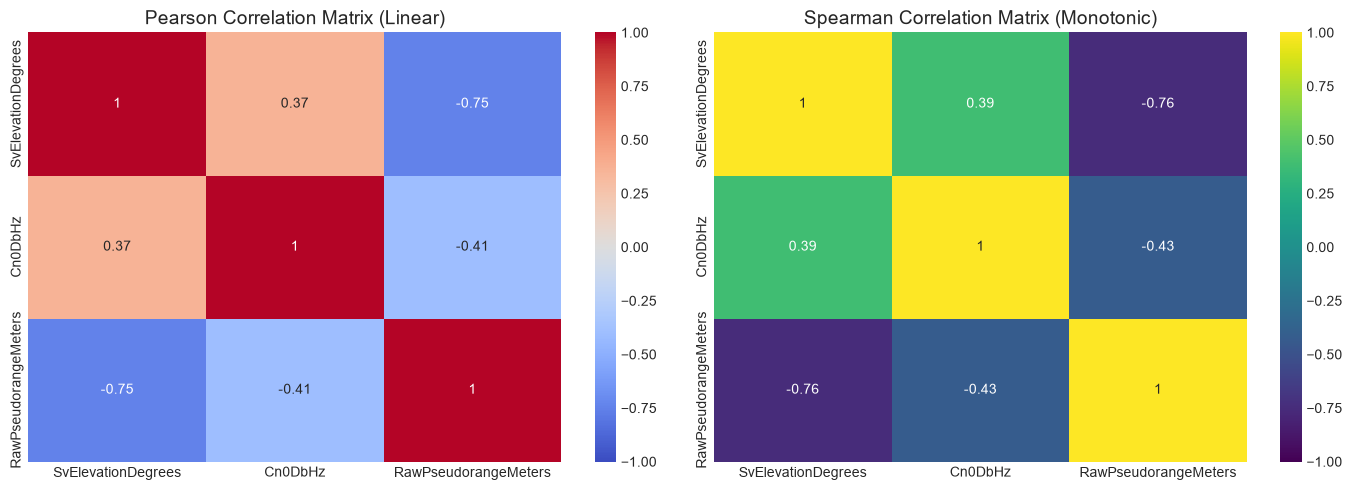

Cramér's V Correlation (SignalType vs Binned C/N0): 0.170


Signal_Strength_Bin,Weak,Moderate,Strong,Excellent
SignalType,,,,
GAL_E1_C_P,2581,2926,2477,2036
GAL_E5A_Q,3719,3187,2630,499
GLO_G1_CA,1816,2132,1795,2721
GPS_L1_CA,3012,2835,3363,5068
GPS_L5_Q,922,965,1790,1761


In [154]:
# 5.1 Continuous Correlations
num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
num_df = df[num_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(num_df.corr(method="pearson"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Correlation Matrix (Linear)")

sns.heatmap(num_df.corr(method="spearman"), annot=True, cmap="viridis", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Correlation Matrix (Monotonic)")

plt.tight_layout()
plt.show()

# 5.2 Categorical Correlation (Cramér's V)
df_binned = df.copy()
df_binned["Signal_Strength_Bin"] = pd.qcut(df_binned["Cn0DbHz"], q=4, labels=["Weak", "Moderate", "Strong", "Excellent"])
contingency = pd.crosstab(df_binned["SignalType"], df_binned["Signal_Strength_Bin"])

chi2 = stats.chi2_contingency(contingency)[0]
n = contingency.sum().sum()
phi2 = chi2 / n
r, k = contingency.shape
v_stat = np.sqrt(phi2 / min(k - 1, r - 1))

print(f"Cramér's V Correlation (SignalType vs Binned C/N0): {v_stat:.3f}")
display(contingency)



---
## 6. Comprehensive Visualizations Suite
Visualizing the distributions and interactions allows us to spot data skews, signal degradation patterns, and constellation biases.
    


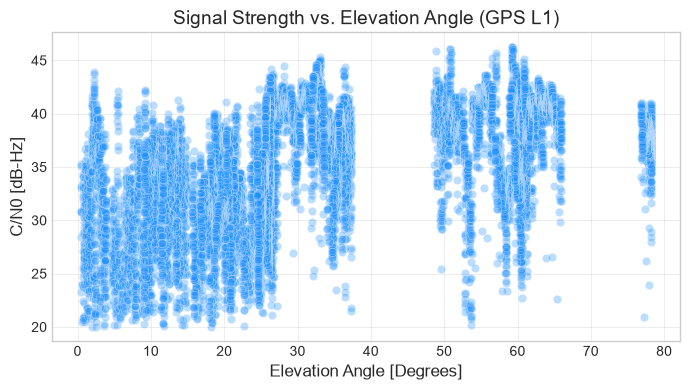

In [155]:
# Filter GPS L1 satellites for a clean physical representation
clean_gps = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

plt.figure(figsize=(7, 4))

# Plot 1: Elevation vs Signal Strength
sns.scatterplot(data=clean_gps, x="SvElevationDegrees", y="Cn0DbHz", alpha=0.3, color="dodgerblue")
plt.title("Signal Strength vs. Elevation Angle (GPS L1)")
plt.xlabel("Elevation Angle [Degrees]")
plt.ylabel("C/N0 [dB-Hz]")


plt.tight_layout()
plt.show()



### 6.1 Constellation & Signal Comparisons
How do different satellite systems (GPS, GLONASS, Galileo) compare in terms of signal strength and elevation availability?
    


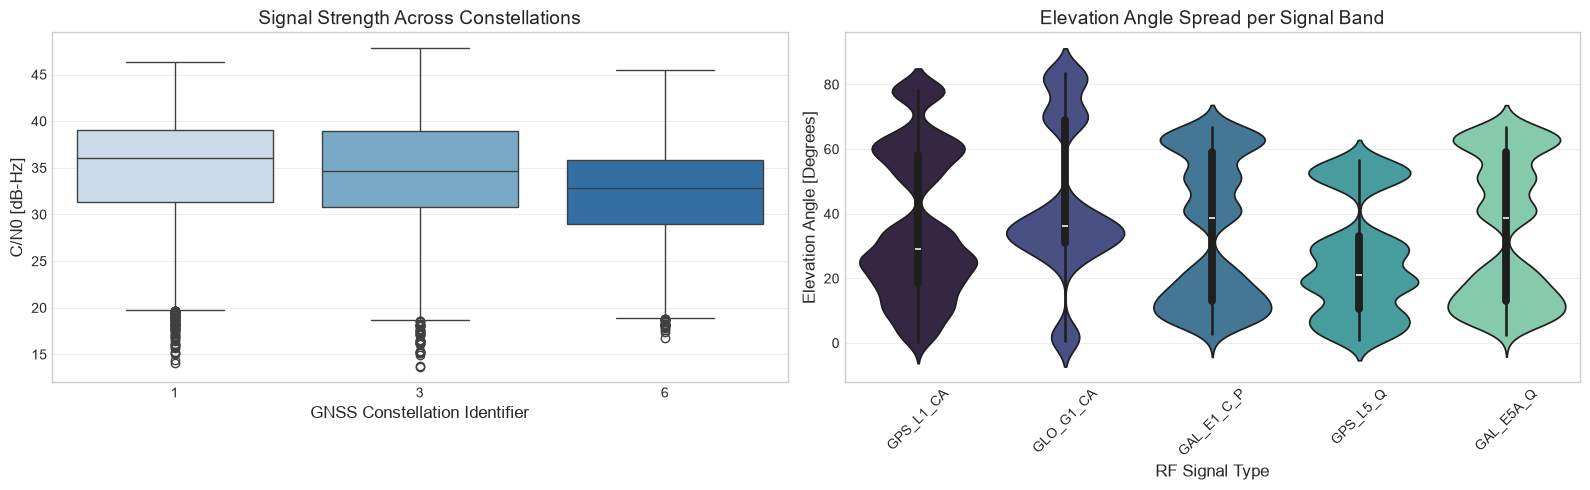

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Boxplot of C/N0 by Constellation
sns.boxplot(data=df, x="ConstellationType", y="Cn0DbHz", palette="Blues", ax=axes[0])
axes[0].set_title("Signal Strength Across Constellations")
axes[0].set_xlabel("GNSS Constellation Identifier")
axes[0].set_ylabel("C/N0 [dB-Hz]")

# Plot 4: Violinplot of Elevation by Signal Type
sns.violinplot(data=df, x="SignalType", y="SvElevationDegrees", palette="mako", ax=axes[1])
axes[1].set_title("Elevation Angle Spread per Signal Band")
axes[1].set_xlabel("RF Signal Type")
axes[1].set_ylabel("Elevation Angle [Degrees]")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



---
## 7. Time-Series Tracking & Stability
We analyze signal stability over time. Specifically, we isolate the satellite with the *highest* standard deviation in signal strength (most volatile) and the one with the *lowest* (most stable).
    


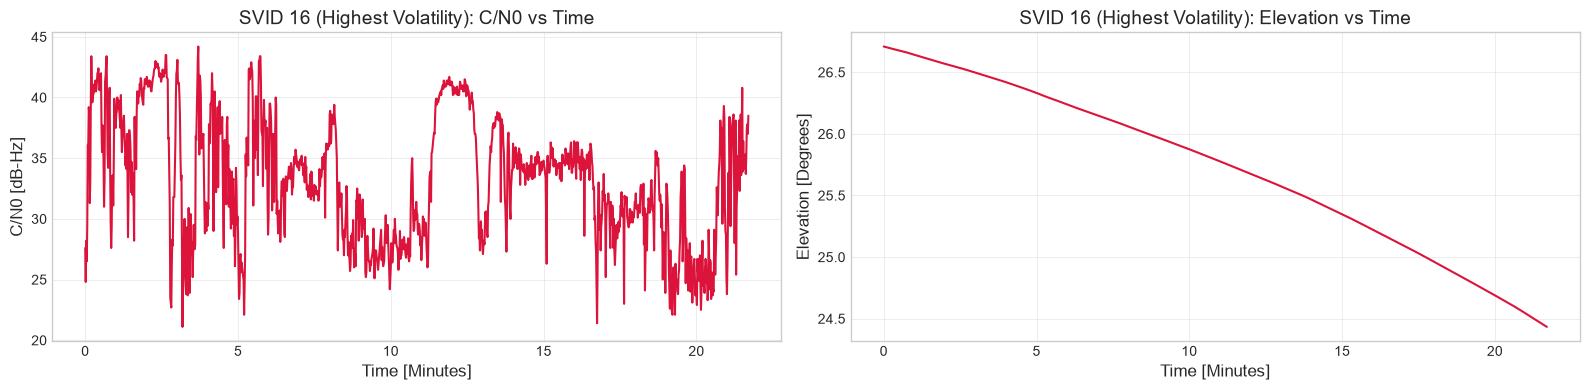

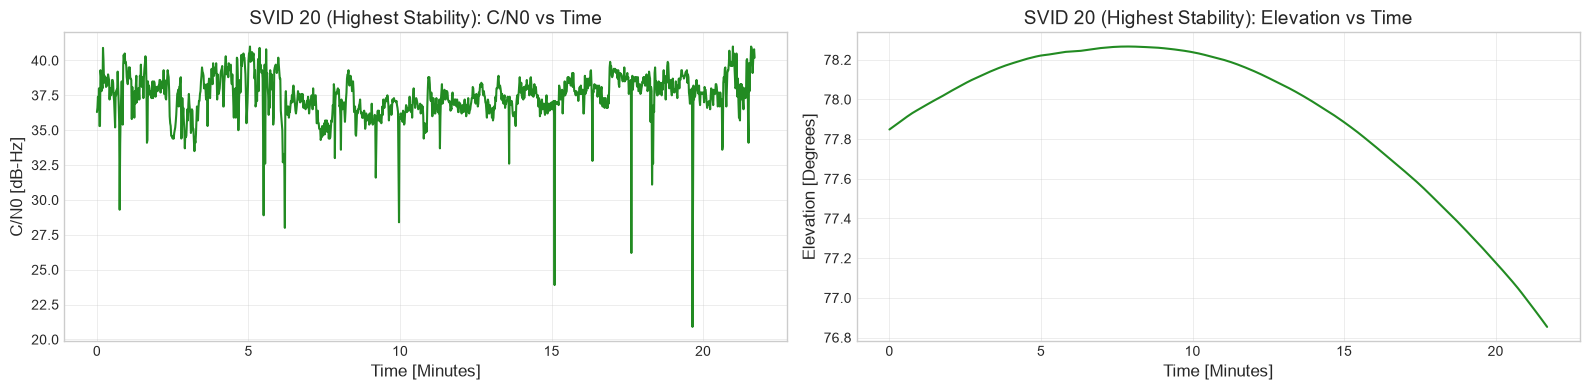

In [157]:
gps_l1 = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

# Filter out satellites with too few observations for valid std calculation
valid_svids = gps_l1.groupby("Svid")["Cn0DbHz"].count()[lambda x: x >= 50].index
gps_l1_filtered = gps_l1[gps_l1["Svid"].isin(valid_svids)]

# Calculate standard deviation per satellite
std_per_svid = gps_l1_filtered.groupby("Svid")["Cn0DbHz"].std()
svid_most_volatile = std_per_svid.idxmax()
svid_most_stable = std_per_svid.idxmin()

def plot_svid_time_series(svid, title_suffix, color):
    data = gps_l1_filtered[gps_l1_filtered["Svid"] == svid].copy()
    data['TimeMinutes'] = (data['TimeNanos'] - data['TimeNanos'].min()) / 1e9 / 60

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    sns.lineplot(data=data, x="TimeMinutes", y="Cn0DbHz", color=color, ax=axes[0])
    axes[0].set_title(f"SVID {svid} ({title_suffix}): C/N0 vs Time")
    axes[0].set_xlabel("Time [Minutes]")
    axes[0].set_ylabel("C/N0 [dB-Hz]")

    sns.lineplot(data=data, x="TimeMinutes", y="SvElevationDegrees", color=color, ax=axes[1])
    axes[1].set_title(f"SVID {svid} ({title_suffix}): Elevation vs Time")
    axes[1].set_xlabel("Time [Minutes]")
    axes[1].set_ylabel("Elevation [Degrees]")

    plt.tight_layout()
    plt.show()

# Plot the most volatile and most stable satellites
plot_svid_time_series(svid_most_volatile, "Highest Volatility", "crimson")
plot_svid_time_series(svid_most_stable, "Highest Stability", "forestgreen")



---
## 8. Index Structure & Monotonicity
For sequential GNSS data, ensuring the data is strictly ordered in time without index duplicates is critical before applying smoothing filters like Kalman Filters.
    


In [158]:
print(f"Is DataFrame Index Unique? -> {df.index.is_unique}")
print(f"Is DataFrame Index Monotonically Increasing? -> {df.index.is_monotonic_increasing}")

if "ReceivedSvTimeNanosSinceGpsEpoch" in df.columns:
    is_time_sorted = df["ReceivedSvTimeNanosSinceGpsEpoch"].is_monotonic_increasing
    print(f"Is Dataset Monotonically Sorted by GPS Time? -> {is_time_sorted}")
else:
    print("Column 'ReceivedSvTimeNanosSinceGpsEpoch' not found for strict time check.")


Is DataFrame Index Unique? -> True
Is DataFrame Index Monotonically Increasing? -> True
Is Dataset Monotonically Sorted by GPS Time? -> False



---
## 9. Domain Feature Engineering (Bonus)
A major objective of processing GNSS data is identifying **Line-of-Sight (LOS)** vs. **Multipath** signals. Multipath occurs when signals bounce off buildings, degrading location accuracy.

We engineer a new boolean feature `Is_Reliable_LOS`. Based on domain knowledge, a signal is generally considered a reliable LOS if:
1. It is high in the sky ($\geq 40^\circ$) reducing the chance of hitting buildings.
2. It has a strong signal-to-noise ratio ($\geq 37$ dB-Hz).
    


Reliable Line-of-Sight (LOS) Measurements in Dataset: 16.71%


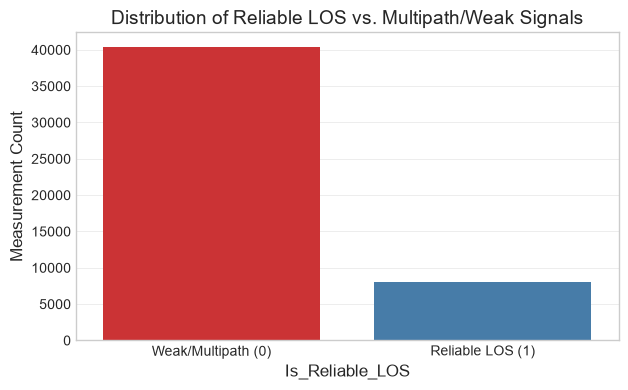

EDA Pipeline Complete.


In [159]:
# Engineer the new feature
df["Is_Reliable_LOS"] = np.where(
    (df["SvElevationDegrees"] >= 40) & (df["Cn0DbHz"] >= 37),
    1, 
    0
)

los_percentage = df["Is_Reliable_LOS"].mean() * 100
print(f"Reliable Line-of-Sight (LOS) Measurements in Dataset: {los_percentage:.2f}%")

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Is_Reliable_LOS", palette="Set1")
plt.title("Distribution of Reliable LOS vs. Multipath/Weak Signals")
plt.xticks(ticks=[0, 1], labels=["Weak/Multipath (0)", "Reliable LOS (1)"])
plt.ylabel("Measurement Count")
plt.show()

print("EDA Pipeline Complete.")
